In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import os


'c:\\Users\\gabriel.battcock\\OneDrive - World Food Programme\\Documents\\MIMI_mac\\git\\sri_lanka'

In [6]:
acled_data = pd.read_csv('../../data/raw/features/ACLED_2018.csv')
ml_targets = pd.read_csv("../../data/processed/sl_ml_targets_2025-10-06.csv")
hh_info = pd.read_csv("../../data/processed/hh_info.csv")
adm2_average = pd.read_csv("../../data/processed/adm2_average.csv")

In [15]:
acled_data['event_date'] = pd.to_datetime(acled_data['event_date'], format='%Y-%m-%d')
acled_data['event_month'] = acled_data['event_date'].dt.month
acled_data
# count the number of events per month 
# acled_data.groupby('event_month')
acled_counts2018 = acled_data[['event_month','admin2']].value_counts()
acled_counts2018 = pd.DataFrame(acled_counts2018).reset_index()
acled_counts2018

,event_month,admin2,count
0,11,Colombo,26
1,12,Colombo,25
2,9,Colombo,18
3,10,Colombo,17
4,7,Colombo,15
...,...,...,...
143,7,Anuradhapura,1
144,6,Kalutara,1
145,6,Jaffna,1
146,5,Ratnapura,1


In [8]:
# look at types of acled variable
 
acled_data['interaction'].unique()
acled_data['admin2'].unique()

array(['Nuwara Eliya', 'Colombo', 'Mannar', 'Hambantota', 'Vavuniya', 'Kegalle', 'Moneragala', 'Badulla', 'Anuradhapura', 'Galle',
       'Jaffna', 'Kalutara', 'Batticaloa', 'Gampaha', 'Puttalam', 'Kandy', 'Kilinochchi', 'Matara', 'Matale', 'Mullaitivu',
       'Ratnapura', 'Kurunegala', 'Polonnaruwa', 'Trincomalee', 'Ampara'], dtype=object)

In [45]:

def merge_district_codes(df):
    # District code mapping
    districts = [
        {"adm2": 81, "admin2": "Badulla"}, {"adm2": 11, "admin2": "Colombo"},
        {"adm2": 12, "admin2": "Gampaha"}, {"adm2": 41, "admin2": "Jaffna"},
        {"adm2": 13, "admin2": "Kalutara"}, {"adm2": 21, "admin2": "Kandy"},
        {"adm2": 92, "admin2": "Kegalle"}, {"adm2": 61, "admin2": "Kurunegala"},
        {"adm2": 43, "admin2": "Mannar"}, {"adm2": 22, "admin2": "Matale"},
        {"adm2": 82, "admin2": "Moneragala"}, {"adm2": 23, "admin2": "Nuwara Eliya"},
        {"adm2": 72, "admin2": "Polonnaruwa"}, {"adm2": 91, "admin2": "Ratnapura"},
        {"adm2": 53, "admin2": "Trincomalee"}, {"adm2": 44, "admin2": "Vavuniya"},
        {"adm2": 71, "admin2": "Anuradhapura"}, {"adm2": 44, "admin2": "Mullaitivu"},
        {"adm2": 52, "admin2": "Ampara"},{"adm2":52, "admin2": "Batticaloa"},
        {"adm2": 33, "admin2": "Hambantota"}, {"adm2": 45, "admin2": "Kilinochchi"},
        {"adm2": 62, "admin2": "Puttalam"}, {"adm2": 31, "admin2": "Galle"},
        {"adm2": 32, "admin2": "Matara"}
        
    ]
    
    df_districts = pd.DataFrame(districts)
    
    # Merge to assign adm2 codes
    merged = df.merge(df_districts, on='admin2', how='left')
    
    return merged


matched_data = merge_district_codes(acled_counts2018)

matched_data

,event_month,admin2,count,adm2
0,11,Colombo,26,11
1,12,Colombo,25,11
2,9,Colombo,18,11
3,10,Colombo,17,11
4,7,Colombo,15,11
...,...,...,...,...
143,7,Anuradhapura,1,71
144,6,Kalutara,1,13
145,6,Jaffna,1,41
146,5,Ratnapura,1,91


In [46]:
matched_data = matched_data.pivot(index="event_month", columns="admin2", values="count").fillna(0)

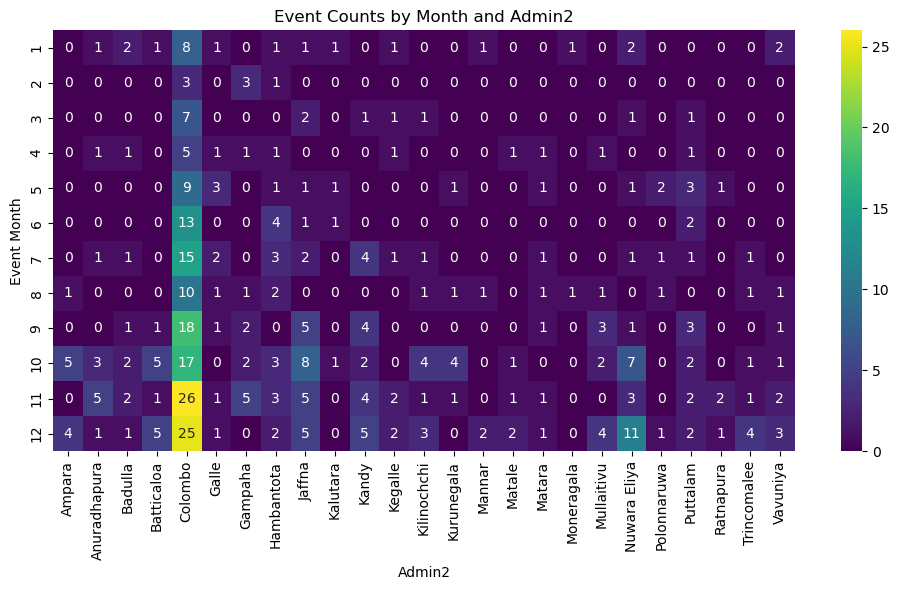

In [47]:


plt.figure(figsize=(10, 6))
sns.heatmap(matched_data, cmap="viridis", annot=True, fmt=".0f")
plt.title("Event Counts by Month and Admin2")
plt.xlabel("Admin2")
plt.ylabel("Event Month")
plt.tight_layout()
plt.show()

